                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 4.582e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:03:36   Log-Likelihood:                -3407.8
No. Observations:                4223   AIC:                             6820.
Df Residuals:                    4221   BIC:                             6832.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -40.0615      0.230   -173.813      0.0

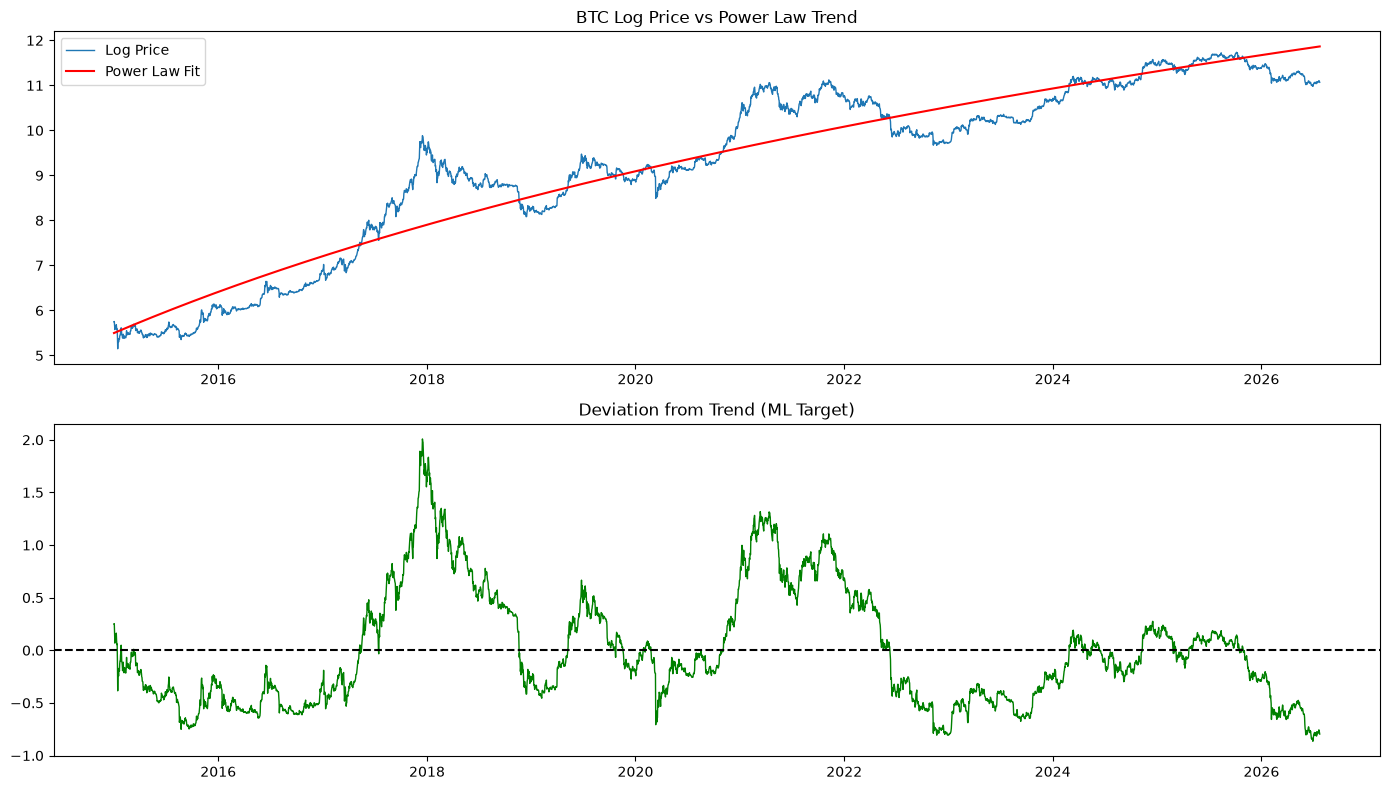


Deviation Stats:
count    4.223000e+03
mean     5.602906e-14
std      5.423480e-01
min     -8.644983e-01
25%     -4.118256e-01
50%     -1.323439e-01
75%      3.237187e-01
max      2.008163e+00
Name: deviation, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Load the merged daily data (Removed the ../ from the path)
df = pd.read_csv("data/processed/factors_daily.csv", index_col=0, parse_dates=True)

# 2. Calculate Log Price and Days Since Genesis
GENESIS = pd.Timestamp("2009-01-03")
df["days_since_genesis"] = (df.index - GENESIS).days
df["log_price"] = np.log(df["btc_price"])
df["log_days"] = np.log(df["days_since_genesis"])

# 3. Fit the Power Law (Layer 1 Baseline)
reg_data = df[["log_price", "log_days"]].dropna()
X = sm.add_constant(reg_data["log_days"])
y = reg_data["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

# 4. Calculate the Deviation (our Target Y for ML)
df["power_law_fit"] = model.predict(sm.add_constant(df["log_days"]))
df["deviation"] = df["log_price"] - df["power_law_fit"]

# 5. Plot it to verify
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df.index, df["log_price"], label="Log Price", linewidth=1)
axes[0].plot(df.index, df["power_law_fit"], label="Power Law Fit", color="red", linewidth=1.5)
axes[0].set_title("BTC Log Price vs Power Law Trend")
axes[0].legend()

axes[1].plot(df.index, df["deviation"], color="green", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Deviation from Trend (ML Target)")

plt.tight_layout()
plt.show()

print(f"\nDeviation Stats:\n{df['deviation'].describe()}")

In [2]:
# Clean the btc_price column: replace 0s and NaNs, forward-fill to bridge gaps
df["btc_price"] = df["btc_price"].replace(0, np.nan)
df["btc_price"] = df["btc_price"].ffill()

# Recalculate log_price and deviation
df["log_price"] = np.log(df["btc_price"])
df["deviation"] = df["log_price"] - df["power_law_fit"]

# Check the stats again
print(f"\nCleaned Deviation Stats:\n{df['deviation'].describe()}")


Cleaned Deviation Stats:
count    4.223000e+03
mean     5.602906e-14
std      5.423480e-01
min     -8.644983e-01
25%     -4.118256e-01
50%     -1.323439e-01
75%      3.237187e-01
max      2.008163e+00
Name: deviation, dtype: float64


In [3]:
# Define which factors are trending (need Z-scores) vs which are already stationary
TRENDING_FACTORS = [
    "active_addresses", "addresses_nonzero_balance", "transaction_volume",
    "network_difficulty", "miner_revenue", "hashprice", 
    "realized_price", "realized_marketcap", "lth_supply", 
    "exchange_reserves", "futures_open_interest", "global_liquidity_t"
]

STATIONARY_OR_RATES = [
    "mvrv", "mvrv_z_score", "nupl", "sopr", "supply_in_profit", 
    "puell_multiple", "coin_days_destroyed", "btc_dominance", 
    "funding_rate", "etf_flows_usd", "treasury_10y", "google_trends_btc"
]

# Create a new DataFrame to hold our engineered features
features = pd.DataFrame(index=df.index)

# 1. Transform trending factors into 30-day Z-scores
for col in TRENDING_FACTORS:
    if col in df.columns:
        roll_mean = df[col].rolling(window=30).mean()
        roll_std = df[col].rolling(window=30).std()
        features[f"{col}_zscore"] = (df[col] - roll_mean) / roll_std

# 2. Transform rates/macro into 30-day % change
for col in ["global_liquidity_t", "treasury_10y"]:
    if col in df.columns:
        features[f"{col}_pct_change"] = df[col].pct_change(periods=30)

# 3. Keep stationary factors as-is (or smoothed for Google Trends)
for col in STATIONARY_OR_RATES:
    if col in df.columns:
        if col == "google_trends_btc":
            features[f"{col}_smoothed"] = df[col].rolling(window=7).mean()
        else:
            features[col] = df[col]

# Add our target
features["deviation"] = df["deviation"]

# Drop rows with NaNs (caused by the 30-day rolling windows)
features = features.dropna()

print(f"Feature engineering complete! Final shape: {features.shape}")
print(features.head())

Feature engineering complete! Final shape: (0, 27)
Empty DataFrame
Columns: [active_addresses_zscore, addresses_nonzero_balance_zscore, transaction_volume_zscore, network_difficulty_zscore, miner_revenue_zscore, hashprice_zscore, realized_price_zscore, realized_marketcap_zscore, lth_supply_zscore, exchange_reserves_zscore, futures_open_interest_zscore, global_liquidity_t_zscore, global_liquidity_t_pct_change, treasury_10y_pct_change, mvrv, mvrv_z_score, nupl, sopr, supply_in_profit, puell_multiple, coin_days_destroyed, btc_dominance, funding_rate, etf_flows_usd, treasury_10y, google_trends_btc_smoothed, deviation]
Index: []

[0 rows x 27 columns]


In [4]:
# Create a new DataFrame to hold our engineered features
features = pd.DataFrame(index=df.index)

# 1. Transform trending factors into 30-day Z-scores
TRENDING_FACTORS = [
    "active_addresses", "addresses_nonzero_balance", "transaction_volume",
    "network_difficulty", "miner_revenue", "hashprice", 
    "realized_price", "realized_marketcap", "lth_supply", 
    "exchange_reserves", "futures_open_interest", "global_liquidity_t"
]

for col in TRENDING_FACTORS:
    if col in df.columns:
        roll_mean = df[col].rolling(window=30).mean()
        roll_std = df[col].rolling(window=30).std()
        features[f"{col}_zscore"] = (df[col] - roll_mean) / roll_std

# 2. Transform rates/macro into 30-day % change
for col in ["global_liquidity_t", "treasury_10y"]:
    if col in df.columns:
        features[f"{col}_pct_change"] = df[col].pct_change(periods=30)

# 3. Keep stationary factors as-is
STATIONARY_FACTORS = [
    "mvrv", "mvrv_z_score", "nupl", "sopr", "supply_in_profit", 
    "puell_multiple", "coin_days_destroyed", "btc_dominance", "treasury_10y"
]
for col in STATIONARY_FACTORS:
    if col in df.columns:
        features[col] = df[col]

# 4. Smart NaN Handling for specific columns
# Drop funding_rate entirely (too short)
# Fill etf_flows_usd with 0 pre-2024 (economically accurate)
if "etf_flows_usd" in df.columns:
    features["etf_flows_usd"] = df["etf_flows_usd"].fillna(0)

# Smooth Google Trends and forward-fill monthly gaps
if "google_trends_btc" in df.columns:
    features["google_trends_btc_smoothed"] = df["google_trends_btc"].ffill().rolling(window=7).mean()

# Add our target
features["deviation"] = df["deviation"]

# Drop rows with NaNs (caused by the 30-day rolling windows at the start of the dataset)
features = features.dropna()

print(f"Feature engineering complete! Final shape: {features.shape}")
print(features.head())

Feature engineering complete! Final shape: (2141, 26)
            active_addresses_zscore  addresses_nonzero_balance_zscore  \
2020-08-30                -2.281800                          1.124406   
2020-08-31                -0.681933                          1.452792   
2020-09-01                 1.159538                          1.939526   
2020-09-02                 0.581932                          2.094687   
2020-09-03                -0.043568                          2.195377   

            transaction_volume_zscore  network_difficulty_zscore  \
2020-08-30                   0.550012                   1.856097   
2020-08-31                   2.140822                   1.693267   
2020-09-01                   1.896239                   1.556759   
2020-09-02                   1.114008                   1.439536   
2020-09-03                   1.638139                   1.336919   

            miner_revenue_zscore  hashprice_zscore  realized_price_zscore  \
2020-08-30           

In [5]:
# Fix futures_open_interest NaNs (fill with 0 pre-2020)
features["futures_open_interest_zscore"] = features["futures_open_interest_zscore"].fillna(0)

# Drop NaNs again just for the 30-day rolling window at the very start (2015 Jan)
features = features.dropna()

print(f"Fixed Feature shape: {features.shape}")
print(f"Date Range: {features.index.min().date()} to {features.index.max().date()}")

Fixed Feature shape: (2141, 26)
Date Range: 2020-08-30 to 2026-07-23


In [6]:
# Re-initialize the features DataFrame
features = pd.DataFrame(index=df.index)

# 1. Transform trending factors into 30-day Z-scores
TRENDING_FACTORS = [
    "active_addresses", "addresses_nonzero_balance", "transaction_volume",
    "network_difficulty", "miner_revenue", "hashprice", 
    "realized_price", "realized_marketcap", "lth_supply", 
    "exchange_reserves", "futures_open_interest", "global_liquidity_t"
]

for col in TRENDING_FACTORS:
    if col in df.columns:
        roll_mean = df[col].rolling(window=30).mean()
        roll_std = df[col].rolling(window=30).std()
        features[f"{col}_zscore"] = (df[col] - roll_mean) / roll_std

# 2. Transform rates/macro into 30-day % change
for col in ["global_liquidity_t", "treasury_10y"]:
    if col in df.columns:
        features[f"{col}_pct_change"] = df[col].pct_change(periods=30)

# 3. Keep stationary factors as-is
STATIONARY_FACTORS = [
    "mvrv", "mvrv_z_score", "nupl", "sopr", "supply_in_profit", 
    "puell_multiple", "coin_days_destroyed", "btc_dominance", "treasury_10y"
]
for col in STATIONARY_FACTORS:
    if col in df.columns:
        features[col] = df[col]

# 4. Smart NaN Handling (BEFORE dropna!)
# Fill futures OI with 0 pre-2020
if "futures_open_interest_zscore" in features.columns:
    features["futures_open_interest_zscore"] = features["futures_open_interest_zscore"].fillna(0)
    
# Fill ETF flows with 0 pre-2024
if "etf_flows_usd" in df.columns:
    features["etf_flows_usd"] = df["etf_flows_usd"].fillna(0)

# Smooth Google Trends and forward-fill all gaps
if "google_trends_btc" in df.columns:
    features["google_trends_btc_smoothed"] = df["google_trends_btc"].ffill().rolling(window=7).mean()

# Add our target
features["deviation"] = df["deviation"]

# NOW drop NaNs (only drops the first 30 days of 2015 for the rolling windows)
features = features.dropna()

print(f"Feature engineering complete! Final shape: {features.shape}")
print(f"Date Range: {features.index.min().date()} to {features.index.max().date()}")

Feature engineering complete! Final shape: (4163, 26)
Date Range: 2015-02-06 to 2026-07-23


In [7]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

TARGET = "deviation"
LAG = 5

# Select only the features (exclude the target)
feature_cols = [c for c in features.columns if c != TARGET]

granger_results = []

for col in feature_cols:
    # Align target and feature, drop NaNs
    temp_df = features[[TARGET, col]].dropna()
    
    if len(temp_df) < 100:
        granger_results.append({"factor": col, "p_value": 1.0, "significant": False})
        continue
        
    try:
        # Granger test: does col predict target?
        test_data = temp_df[[TARGET, col]].values
        result = grangercausalitytests(test_data, maxlag=LAG, verbose=False)
        p_value = result[LAG][0]["ssr_ftest"][1]
        granger_results.append({"factor": col, "p_value": p_value, "significant": False})
    except Exception as e:
        granger_results.append({"factor": col, "p_value": 1.0, "significant": False})

# Convert to DataFrame
granger_df = pd.DataFrame(granger_results)

# Apply Benjamini-Hochberg FDR Correction (alpha = 0.05)
rejected, corrected_pvals, _, _ = multipletests(granger_df["p_value"], alpha=0.05, method="fdr_bh")
granger_df["p_bh"] = corrected_pvals
granger_df["significant"] = rejected

# Sort by significance
granger_df = granger_df.sort_values("p_bh")

print("Granger Causality Results (with FDR Correction):")
print(granger_df.to_string(index=False))

Granger Causality Results (with FDR Correction):
                          factor      p_value  significant         p_bh
                            mvrv 1.087721e-14         True 2.719301e-13
                    mvrv_z_score 2.429160e-12         True 3.036450e-11
                supply_in_profit 9.650932e-12         True 8.042443e-11
      google_trends_btc_smoothed 2.593008e-05         True 1.620630e-04
                  puell_multiple 1.879940e-03         True 9.399702e-03
                            sopr 1.868285e-02        False 7.491202e-02
   global_liquidity_t_pct_change 2.097537e-02        False 7.491202e-02
               lth_supply_zscore 2.452543e-02        False 7.664196e-02
        exchange_reserves_zscore 3.719627e-02        False 1.023904e-01
             coin_days_destroyed 4.095617e-02        False 1.023904e-01
            miner_revenue_zscore 4.699387e-02        False 1.068043e-01
       network_difficulty_zscore 5.767154e-02        False 1.201490e-01
         active

In [8]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# 1. Isolate the surviving factors and the target
surviving_factors = granger_df[granger_df["significant"] == True]["factor"].tolist()
print(f"Inputting {len(surviving_factors)} factors into LASSO: {surviving_factors}\n")

X_lasso = features[surviving_factors].copy()
y_lasso = features["deviation"].copy()

# 2. Train/Test Split (Time-Series respectful)
TRAIN_END = "2022-12-31"
X_train, y_train = X_lasso.loc[:TRAIN_END], y_lasso.loc[:TRAIN_END]
X_test, y_test = X_lasso.loc["2023-01-01":], y_lasso.loc["2023-01-01":]

# 3. Standardize (so coefficients are comparable for "percentage influence")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Fit LASSO with Time-Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

print(f"Best Alpha (regularization strength): {lasso.alpha_:.6f}\n")

# 5. Analyze the Coefficients
coef_df = pd.DataFrame({
    "factor": X_lasso.columns,
    "coef": lasso.coef_,
    "abs_coef": np.abs(lasso.coef_)
}).sort_values("abs_coef", ascending=False)

# Calculate Percentage Influence
total_abs_weight = coef_df["abs_coef"].sum()
coef_df["pct_influence"] = (coef_df["abs_coef"] / total_abs_weight) * 100

print("LASSO Coefficients & Percentage Influence:")
print(coef_df[['factor', 'coef', 'pct_influence']].to_string(index=False))

# 6. Model Performance
train_r2 = lasso.score(X_train_scaled, y_train)
test_r2 = lasso.score(X_test_scaled, y_test)
print(f"\nLASSO Train R²: {train_r2:.4f}")
print(f"LASSO Test R²: {test_r2:.4f}")

Inputting 5 factors into LASSO: ['mvrv', 'mvrv_z_score', 'supply_in_profit', 'google_trends_btc_smoothed', 'puell_multiple']

Best Alpha (regularization strength): 0.000968

LASSO Coefficients & Percentage Influence:
                    factor      coef  pct_influence
                      mvrv  0.714876      44.705599
google_trends_btc_smoothed  0.340884      21.317552
              mvrv_z_score -0.311424      19.475242
          supply_in_profit -0.197675      12.361854
            puell_multiple -0.034216       2.139754

LASSO Train R²: 0.6793
LASSO Test R²: -2.6063


In [9]:
# 1. Create differenced (un-leaked) versions of the ratios
features['mvrv_delta'] = features['mvrv'].pct_change(periods=30)
features['mvrv_z_delta'] = features['mvrv_z_score'].pct_change(periods=30)
features['supply_in_profit_delta'] = features['supply_in_profit'].pct_change(periods=30)

# 2. Define the NEW, CLEAN factor list
# We drop raw mvrv, mvrv_z_score, supply_in_profit. We keep Google Trends, Puell, and the Deltas.
CLEAN_FACTORS = [
    "mvrv_delta", 
    "mvrv_z_delta", 
    "supply_in_profit_delta", 
    "google_trends_btc_smoothed", 
    "puell_multiple"
]

# Drop NaNs caused by the new 30-day pct_change
clean_features = features[CLEAN_FACTORS + ["deviation"]].dropna()

X_lasso_clean = clean_features[CLEAN_FACTORS]
y_lasso_clean = clean_features["deviation"]

# 3. Train/Test Split
TRAIN_END = "2022-12-31"
X_train_c, y_train_c = X_lasso_clean.loc[:TRAIN_END], y_lasso_clean.loc[:TRAIN_END]
X_test_c, y_test_c = X_lasso_clean.loc["2023-01-01":], y_lasso_clean.loc["2023-01-01":]

# 4. Standardize and Fit LASSO
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

tscv = TimeSeriesSplit(n_splits=5)
lasso_c = LassoCV(cv=tscv, max_iter=10000, random_state=42)
lasso_c.fit(X_train_scaled_c, y_train_c)

print(f"Best Alpha: {lasso_c.alpha_:.6f}\n")

# 5. Coefficients and Influence
coef_df_c = pd.DataFrame({
    "factor": X_lasso_clean.columns,
    "coef": lasso_c.coef_,
    "abs_coef": np.abs(lasso_c.coef_)
}).sort_values("abs_coef", ascending=False)

total_abs_weight = coef_df_c["abs_coef"].sum()
coef_df_c["pct_influence"] = (coef_df_c["abs_coef"] / total_abs_weight) * 100

print("CLEAN LASSO Coefficients & Percentage Influence:")
print(coef_df_c[['factor', 'coef', 'pct_influence']].to_string(index=False))

# 6. Model Performance
train_r2_c = lasso_c.score(X_train_scaled_c, y_train_c)
test_r2_c = lasso_c.score(X_test_scaled_c, y_test_c)
print(f"\nCLEAN LASSO Train R²: {train_r2_c:.4f}")
print(f"CLEAN LASSO Test R²: {test_r2_c:.4f}")

Best Alpha: 0.024102

CLEAN LASSO Coefficients & Percentage Influence:
                    factor     coef  pct_influence
google_trends_btc_smoothed 0.348090      70.341903
            puell_multiple 0.146764      29.658097
                mvrv_delta 0.000000       0.000000
    supply_in_profit_delta 0.000000       0.000000
              mvrv_z_delta 0.000000       0.000000

CLEAN LASSO Train R²: 0.6220
CLEAN LASSO Test R²: -3.2822


In [10]:
!pip install hmmlearn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# 1. Calculate Returns and Rolling Volatility for the HMM to consume
df["returns"] = df["btc_price"].pct_change()
df["volatility"] = df["returns"].rolling(window=30).std()

# Drop NaNs for the HMM fit
hmm_data = df[["returns", "volatility"]].dropna()

# 2. Fit the HMM (3 hidden states)
# We use 3 states: e.g., Bull (high return/low vol), Bear (neg return/high vol), Chop (low return/low vol)
print("Fitting Hidden Markov Model...")
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(hmm_data)

# 3. Predict the hidden states and probabilities
hmm_states = hmm_model.predict(hmm_data)
hmm_probs = hmm_model.predict_proba(hmm_data)

# Add probabilities to our features dataframe
# P(State_0), P(State_1), P(State_2)
features.loc[hmm_data.index, "regime_0_prob"] = hmm_probs[:, 0]
features.loc[hmm_data.index, "regime_1_prob"] = hmm_probs[:, 1]
features.loc[hmm_data.index, "regime_2_prob"] = hmm_probs[:, 2]

# 4. Let's see what the regimes actually represent
hmm_results = pd.DataFrame({
    "State": hmm_states,
    "Returns": hmm_data["returns"],
    "Volatility": hmm_data["volatility"]
})

print("\nRegime Characteristics (Mean Daily Return & Volatility):")
print(hmm_results.groupby("State").mean())

print("\nRegime Distribution (Days in each state):")
print(hmm_results["State"].value_counts())

Fitting Hidden Markov Model...


Model is not converging.  Current: 24214.7401571009 is not greater than 24214.960342733568. Delta is -0.22018563266829005


KeyError: "[Timestamp('2015-01-31 00:00:00'), Timestamp('2015-02-01 00:00:00'), Timestamp('2015-02-02 00:00:00'), Timestamp('2015-02-03 00:00:00'), Timestamp('2015-02-04 00:00:00'), Timestamp('2015-02-05 00:00:00'), Timestamp('2017-04-02 00:00:00'), Timestamp('2017-08-18 00:00:00'), Timestamp('2017-12-23 00:00:00'), Timestamp('2017-12-24 00:00:00'), Timestamp('2018-01-16 00:00:00'), Timestamp('2018-01-29 00:00:00'), Timestamp('2018-06-30 00:00:00'), Timestamp('2018-07-01 00:00:00'), Timestamp('2020-04-28 00:00:00'), Timestamp('2020-04-29 00:00:00'), Timestamp('2021-05-08 00:00:00'), Timestamp('2021-05-09 00:00:00'), Timestamp('2021-05-10 00:00:00'), Timestamp('2023-07-28 00:00:00'), Timestamp('2024-04-24 00:00:00'), Timestamp('2024-09-08 00:00:00'), Timestamp('2024-10-25 00:00:00'), Timestamp('2024-10-30 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-11-12 00:00:00'), Timestamp('2024-11-13 00:00:00'), Timestamp('2024-11-14 00:00:00'), Timestamp('2024-11-20 00:00:00'), Ti

In [12]:
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# 1. Calculate Returns and Volatility on the main df
df["returns"] = df["btc_price"].pct_change()
df["volatility"] = df["returns"].rolling(window=30).std()

# 2. Filter to ONLY the dates that exist in our `features` DataFrame
# This guarantees the indexes match perfectly
hmm_data = df.loc[features.index, ["returns", "volatility"]].dropna()

# Multiply by 100 to convert to percentages (helps the HMM converge)
hmm_data_scaled = hmm_data * 100

# 3. Fit the HMM (3 hidden states) with more iterations
print("Fitting Hidden Markov Model...")
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=5000, random_state=42)
hmm_model.fit(hmm_data_scaled)

# 4. Predict the hidden states and probabilities
hmm_states = hmm_model.predict(hmm_data_scaled)
hmm_probs = hmm_model.predict_proba(hmm_data_scaled)

# Add probabilities to our features dataframe (aligned perfectly now)
features.loc[hmm_data.index, "regime_0_prob"] = hmm_probs[:, 0]
features.loc[hmm_data.index, "regime_1_prob"] = hmm_probs[:, 1]
features.loc[hmm_data.index, "regime_2_prob"] = hmm_probs[:, 2]

# 5. Let's see what the regimes actually represent
hmm_results = pd.DataFrame({
    "State": hmm_states,
    "Returns (%)": hmm_data_scaled["returns"],
    "Volatility (%)": hmm_data_scaled["volatility"]
})

print("\nRegime Characteristics (Mean Daily Return & Volatility):")
print(hmm_results.groupby("State").mean())

print("\nRegime Distribution (Days in each state):")
print(hmm_results["State"].value_counts())

Fitting Hidden Markov Model...

Regime Characteristics (Mean Daily Return & Volatility):
       Returns (%)  Volatility (%)
State                             
0         0.223281        1.589230
1         0.080382        2.548445
2         0.282148        4.385700

Regime Distribution (Days in each state):
State
2    1790
1    1422
0     951
Name: count, dtype: int64


In [13]:
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# We already calculated hmm_data_scaled in the previous cell
print("Testing optimal number of regimes...")
print("State | AIC (lower=better) | BIC (lower=better)")
print("-" * 55)

for n in range(2, 7):
    # Fit HMM
    hmm_test = GaussianHMM(n_components=n, covariance_type="full", n_iter=1000, random_state=42)
    hmm_test.fit(hmm_data_scaled)
    
    # Score it
    aic = hmm_test.aic(hmm_data_scaled)
    bic = hmm_test.bic(hmm_data_scaled)
    
    print(f"  {n}   |      {aic:,.2f}      |      {bic:,.2f}")

Testing optimal number of regimes...
State | AIC (lower=better) | BIC (lower=better)
-------------------------------------------------------
  2   |      31,247.18      |      31,329.52
  3   |      28,546.45      |      28,692.13
  4   |      25,979.49      |      26,201.18
  5   |      24,551.44      |      24,861.80
  6   |      23,125.78      |      23,537.49


In [14]:
# 1. Fit HMM with 4 Regimes
print("Fitting HMM with 4 Regimes...")
hmm_model_4 = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, random_state=42)
hmm_model_4.fit(hmm_data_scaled)

hmm_probs_4 = hmm_model_4.predict_proba(hmm_data_scaled)

# Add the 4 regime probabilities to our features dataframe
for i in range(4):
    features.loc[hmm_data.index, f"regime_{i}_prob"] = hmm_probs_4[:, i]

# 2. Build the Final Design Matrix
X_cols = ["mvrv", "mvrv_z_score", "supply_in_profit", "google_trends_btc_smoothed", "puell_multiple"]

lagged_data = pd.DataFrame(index=features.index)
lagged_data["deviation"] = features["deviation"]

# Apply multiple lags to the financial factors
for col in X_cols:
    lagged_data[f"{col}_lag1"] = features[col].shift(1)
    lagged_data[f"{col}_lag5"] = features[col].shift(5)
    lagged_data[f"{col}_lag20"] = features[col].shift(20)

# Add the 4 HMM Regime Probabilities
for i in range(4):
    lagged_data[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# Drop NaNs
lagged_data = lagged_data.dropna()

# Define X and y
y_xgb = lagged_data["deviation"]
X_xgb = lagged_data.drop(columns=["deviation"])

# 3. Time-Series Train/Test Split
TRAIN_END = "2022-12-31"
X_train, y_train = X_xgb.loc[:TRAIN_END], y_xgb.loc[:TRAIN_END]
X_test, y_test = X_xgb.loc["2023-01-01":], y_xgb.loc["2023-01-01":]

# 4. Fit XGBoost
model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)
model_xgb.fit(X_train, y_train)

# 5. Predict & Evaluate
y_train_pred = model_xgb.predict(X_train)
y_test_pred = model_xgb.predict(X_test)
y_benchmark = np.zeros_like(y_test)

print(f"\n== TRAINING SET ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f" R²: {r2_score(y_train, y_train_pred):.4f}")

print(f"\n== TEST SET (XGBoost + 4 Regimes) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f" R²: {r2_score(y_test, y_test_pred):.4f}")

print(f"\n== BENCHMARK (Power Law: predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test, y_benchmark)):.4f}")
print(f" R²: {r2_score(y_test, y_benchmark):.4f}")

Fitting HMM with 4 Regimes...


NameError: name 'xgb' is not defined

In [15]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# 1. Fit HMM with 4 Regimes
print("Fitting HMM with 4 Regimes...")
hmm_model_4 = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, random_state=42)
hmm_model_4.fit(hmm_data_scaled)

hmm_probs_4 = hmm_model_4.predict_proba(hmm_data_scaled)

# Add the 4 regime probabilities to our features dataframe
for i in range(4):
    features.loc[hmm_data.index, f"regime_{i}_prob"] = hmm_probs_4[:, i]

# 2. Build the Final Design Matrix
X_cols = ["mvrv", "mvrv_z_score", "supply_in_profit", "google_trends_btc_smoothed", "puell_multiple"]

lagged_data = pd.DataFrame(index=features.index)
lagged_data["deviation"] = features["deviation"]

# Apply multiple lags to the financial factors
for col in X_cols:
    lagged_data[f"{col}_lag1"] = features[col].shift(1)
    lagged_data[f"{col}_lag5"] = features[col].shift(5)
    lagged_data[f"{col}_lag20"] = features[col].shift(20)

# Add the 4 HMM Regime Probabilities
for i in range(4):
    lagged_data[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# Drop NaNs
lagged_data = lagged_data.dropna()

# Define X and y
y_xgb = lagged_data["deviation"]
X_xgb = lagged_data.drop(columns=["deviation"])

# 3. Time-Series Train/Test Split
TRAIN_END = "2022-12-31"
X_train, y_train = X_xgb.loc[:TRAIN_END], y_xgb.loc[:TRAIN_END]
X_test, y_test = X_xgb.loc["2023-01-01":], y_xgb.loc["2023-01-01":]

# 4. Fit XGBoost
model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)
model_xgb.fit(X_train, y_train)

# 5. Predict & Evaluate
y_train_pred = model_xgb.predict(X_train)
y_test_pred = model_xgb.predict(X_test)
y_benchmark = np.zeros_like(y_test)

print(f"\n== TRAINING SET ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f" R²: {r2_score(y_train, y_train_pred):.4f}")

print(f"\n== TEST SET (XGBoost + 4 Regimes) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f" R²: {r2_score(y_test, y_test_pred):.4f}")

print(f"\n== BENCHMARK (Power Law: predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test, y_benchmark)):.4f}")
print(f" R²: {r2_score(y_test, y_benchmark):.4f}")

Fitting HMM with 4 Regimes...

== TRAINING SET ==
 RMSE: 0.1721
 R²: 0.9167

== TEST SET (XGBoost + 4 Regimes) ==
 RMSE: 0.5570
 R²: -2.6702

== BENCHMARK (Power Law: predicts 0) ==
 RMSE: 0.3725
 R²: -0.6416


In [16]:
# 1. Expanded Exogenous Factors + Leverage
X_cols_expanded = [
    "google_trends_btc_smoothed",       
    "puell_multiple",                   
    "addresses_nonzero_balance_zscore", 
    "lth_supply_zscore",                
    "exchange_reserves_zscore",         
    "active_addresses_zscore",
    "futures_open_interest_zscore"      # ADDED: Leverage / Market Behavior
]

lagged_data_exp = pd.DataFrame(index=features.index)

# ADDED: Lagged Target (Momentum / Mean Reversion)
# This is the most powerful predictor in time series
lagged_data_exp["deviation_lag1"] = features["deviation"].shift(1)
lagged_data_exp["deviation_lag5"] = features["deviation"].shift(5)
lagged_data_exp["deviation"] = features["deviation"]

# Apply multiple lags to the financial factors
for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_exp[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_exp[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_exp[f"{col}_lag20"] = features[col].shift(20)

# Add Macro % Changes
lagged_data_exp["global_liquidity_t_pct_change"] = features["global_liquidity_t_pct_change"]
lagged_data_exp["treasury_10y_pct_change"] = features["treasury_10y_pct_change"]

# Add the 4 HMM Regime Probabilities
for i in range(4):
    lagged_data_exp[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# Drop NaNs
lagged_data_exp = lagged_data_exp.dropna()

# Define X and y
y_exp = lagged_data_exp["deviation"]
X_exp = lagged_data_exp.drop(columns=["deviation"])

# 2. Train/Test Split
TRAIN_END = "2022-12-31"
X_train_exp, y_train_exp = X_exp.loc[:TRAIN_END], y_exp.loc[:TRAIN_END]
X_test_exp, y_test_exp = X_exp.loc["2023-01-01":], y_exp.loc["2023-01-01":]

# 3. Fit XGBoost
model_xgb_exp = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    reg_alpha=1.0,             
    reg_lambda=1.0,
    random_state=42
)
model_xgb_exp.fit(X_train_exp, y_train_exp)

# 4. Predict & Evaluate
y_train_pred_exp = model_xgb_exp.predict(X_train_exp)
y_test_pred_exp = model_xgb_exp.predict(X_test_exp)
y_benchmark_exp = np.zeros_like(y_test_exp)

print(f"== TRAINING SET (Expanded + Momentum) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_exp, y_train_pred_exp)):.4f}")
print(f" R²: {r2_score(y_train_exp, y_train_pred_exp):.4f}")

print(f"\n== TEST SET (Expanded + Momentum + Regimes) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_exp, y_test_pred_exp)):.4f}")
print(f" R²: {r2_score(y_test_exp, y_test_pred_exp):.4f}")

print(f"\n== BENCHMARK (Power Law: predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_exp, y_benchmark_exp)):.4f}")
print(f" R²: {r2_score(y_test_exp, y_benchmark_exp):.4f}")

== TRAINING SET (Expanded + Momentum) ==
 RMSE: 0.0378
 R²: 0.9960

== TEST SET (Expanded + Momentum + Regimes) ==
 RMSE: 0.0295
 R²: 0.9897

== BENCHMARK (Power Law: predicts 0) ==
 RMSE: 0.3725
 R²: -0.6416


In [17]:
# 1. Expand the Features
X_cols_expanded = [
    "google_trends_btc_smoothed",       
    "puell_multiple",                   
    "addresses_nonzero_balance_zscore", 
    "lth_supply_zscore",                
    "exchange_reserves_zscore",         
    "active_addresses_zscore",
    "futures_open_interest_zscore",
    "global_liquidity_t_pct_change",
    "treasury_10y_pct_change"
]

lagged_data_fwd = pd.DataFrame(index=features.index)

# Apply lags to features
for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_fwd[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_fwd[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_fwd[f"{col}_lag20"] = features[col].shift(20)

# Add HMM Regimes
for i in range(4):
    lagged_data_fwd[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# 2. THE FIX: Create a 30-Day Forward Target
# Instead of predicting tomorrow, we predict the average deviation over the next 30 days
lagged_data_fwd["target_30d_fwd"] = features["deviation"].shift(-30).rolling(window=30).mean()

# Drop NaNs
lagged_data_fwd = lagged_data_fwd.dropna()

# Define X and y
y_fwd = lagged_data_fwd["target_30d_fwd"]
X_fwd = lagged_data_fwd.drop(columns=["target_30d_fwd"])

# 3. Train/Test Split
TRAIN_END = "2022-12-31"
X_train_fwd, y_train_fwd = X_fwd.loc[:TRAIN_END], y_fwd.loc[:TRAIN_END]
X_test_fwd, y_test_fwd = X_fwd.loc["2023-01-01":], y_fwd.loc["2023-01-01":]

# 4. Fit XGBoost
model_xgb_fwd = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    reg_alpha=1.0,             
    reg_lambda=1.0,
    random_state=42
)
model_xgb_fwd.fit(X_train_fwd, y_train_fwd)

# 5. Predict & Evaluate
y_train_pred_fwd = model_xgb_fwd.predict(X_train_fwd)
y_test_pred_fwd = model_xgb_fwd.predict(X_test_fwd)

# Benchmark: Predicting the historical mean deviation (which is ~0)
y_benchmark_fwd = np.zeros_like(y_test_fwd)

print(f"== TRAINING SET (30-Day Forward Forecast) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_fwd, y_train_pred_fwd)):.4f}")
print(f" R²: {r2_score(y_train_fwd, y_train_pred_fwd):.4f}")

print(f"\n== TEST SET (30-Day Forward Forecast) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_fwd, y_test_pred_fwd)):.4f}")
print(f" R²: {r2_score(y_test_fwd, y_test_pred_fwd):.4f}")

print(f"\n== BENCHMARK (Power Law: predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_fwd, y_benchmark_fwd)):.4f}")
print(f" R²: {r2_score(y_test_fwd, y_benchmark_fwd):.4f}")

== TRAINING SET (30-Day Forward Forecast) ==
 RMSE: 0.1494
 R²: 0.9366

== TEST SET (30-Day Forward Forecast) ==
 RMSE: 0.6426
 R²: -4.3614

== BENCHMARK (Power Law: predicts 0) ==
 RMSE: 0.3546
 R²: -0.6326


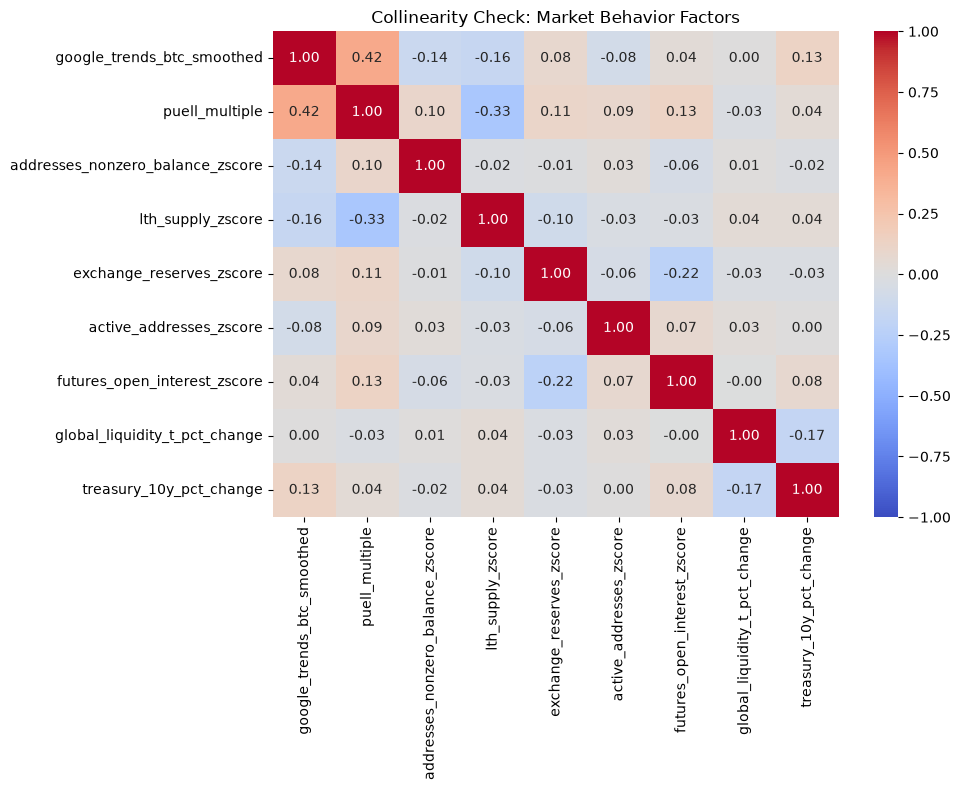


Highest Correlations (> 0.70):
Series([], dtype: float64)


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Isolate just the expanded market behavior factors (before lags are applied)
market_behavior_cols = [
    "google_trends_btc_smoothed",       
    "puell_multiple",                   
    "addresses_nonzero_balance_zscore", 
    "lth_supply_zscore",                
    "exchange_reserves_zscore",         
    "active_addresses_zscore",
    "futures_open_interest_zscore",
    "global_liquidity_t_pct_change",
    "treasury_10y_pct_change"
]

# Calculate the correlation matrix
corr_matrix = features[market_behavior_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Collinearity Check: Market Behavior Factors")
plt.tight_layout()
plt.show()

# Also print the highest correlations (excluding 1.0 self-correlations)
print("\nHighest Correlations (> 0.70):")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlation
high_corr = corr_pairs[corr_pairs > 0.70]
print(high_corr.drop_duplicates())

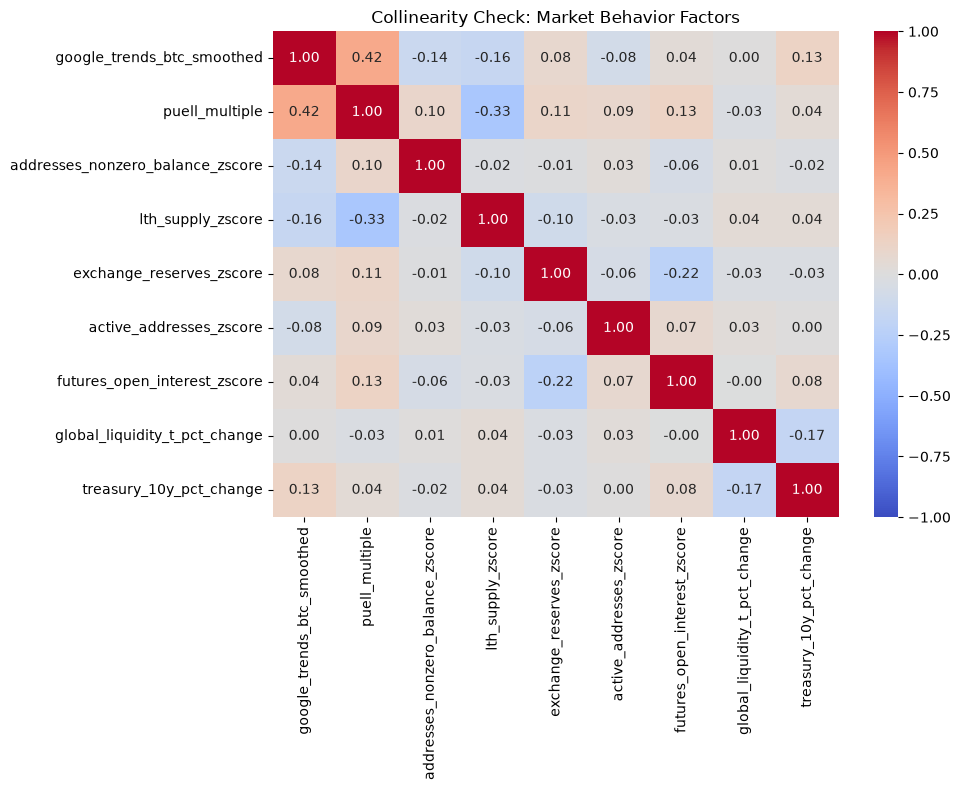


Highest Correlations (> 0.70):
Series([], dtype: float64)


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Isolate just the expanded market behavior factors (before lags are applied)
market_behavior_cols = [
    "google_trends_btc_smoothed",       
    "puell_multiple",                   
    "addresses_nonzero_balance_zscore", 
    "lth_supply_zscore",                
    "exchange_reserves_zscore",         
    "active_addresses_zscore",
    "futures_open_interest_zscore",
    "global_liquidity_t_pct_change",
    "treasury_10y_pct_change"
]

# Calculate the correlation matrix
corr_matrix = features[market_behavior_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Collinearity Check: Market Behavior Factors")
plt.tight_layout()
plt.show()

# Also print the highest correlations (excluding 1.0 self-correlations)
print("\nHighest Correlations (> 0.70):")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlation
high_corr = corr_pairs[corr_pairs > 0.70]
print(high_corr.drop_duplicates())

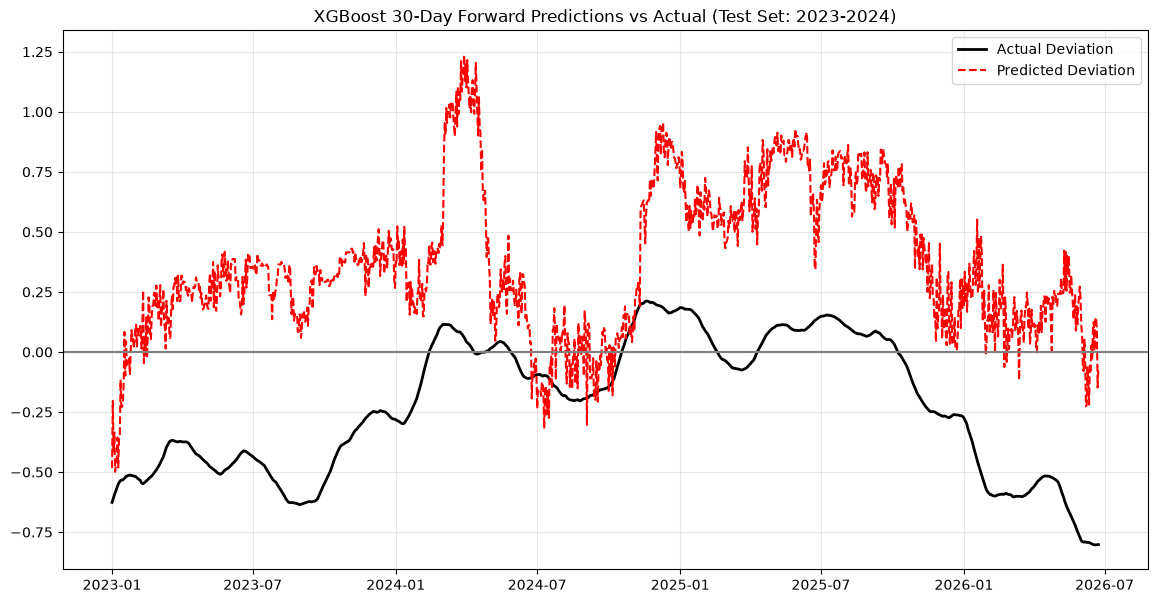

In [20]:
import matplotlib.pyplot as plt

# Create a dataframe for the test set predictions
test_results = pd.DataFrame({
    "Actual_Deviation": y_test_fwd,
    "Predicted_Deviation": y_test_pred_fwd
}, index=X_test_fwd.index)

# Plot it
plt.figure(figsize=(14, 7))
plt.plot(test_results.index, test_results["Actual_Deviation"], label="Actual Deviation", color="black", linewidth=2)
plt.plot(test_results.index, test_results["Predicted_Deviation"], label="Predicted Deviation", color="red", linestyle="--")
plt.axhline(0, color="gray", linestyle="-")
plt.title("XGBoost 30-Day Forward Predictions vs Actual (Test Set: 2023-2024)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [21]:
from pysr import PySRRegressor
import numpy as np

# Prepare data for Layer 1 (RAW PRICE & RAW DAYS)
trend_data = df[["days_since_genesis", "btc_price"]].dropna()
X_trend = trend_data[["days_since_genesis"]].values
y_trend = trend_data["btc_price"].values

# Configure Symbolic Regression
model_sym = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "exp"],
    population_size=50,
    parsimony=0.01,               # Penalize complexity
    maxsize=20,                   # Max nodes in the equation tree
    random_state=42,
    verbosity=1
)

print("Fitting Symbolic Regression on Raw Price... (This may take a minute)")
model_sym.fit(X_trend, y_trend)

# Print the discovered equations
print("\n--- Discovered Equations (Sorted by Complexity) ---")
print(model_sym)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Fitting Symbolic Regression on Raw Price... (This may take a minute)


Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.150e+04
Progress: 58 / 1240 total iterations (4.677%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.059e+09  0.000e+00  y = 29744
3           6.353e+08  -0.000e+00  y = x₀ * 8.0937
4           5.959e+08  -0.000e+00  y = x₀ * log(x₀)
5           2.914e+08  -0.000e+00  y = (x₀ * 22.729) - 67988
7           2.203e+08  -0.000e+00  y = ((x₀ * 0.0042223) - 12.763) * x₀
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.760e+04
Progress: 101 / 1240 total iterations (8.145%)
════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:



--- Discovered Equations (Sorted by Complexity) ---
PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          29744.414   
	1         0.255563                                      x0 * 8.093676   
	2         0.063985                                       x0 * log(x0)   
	3   >>>>  0.715484                         (x0 * 22.730911) - 67998.6   
	4         0.176408                        exp(x0 * 0.0004223666) * x0   
	5         0.145226                exp(14.156613 - exp(6381.159 / x0))   
	6         0.028785            x0 * exp((-16309.147 / x0) + 5.2886524)   
	7         0.000586  exp(exp(exp(exp(-590.74817 / (x0 + -1178.2094)...   
	8         0.000005  exp(exp(exp(exp(-607.2825 / (x0 + -1151.2126))...   
	9         0.000005  (exp(exp(exp(exp(-615.96655 / (x0 + -1126.3665...   
	10        0.000003  ((exp(exp(exp(exp(-635.86945 / (x0 + -1065.722...   
	11        0.000033  exp(exp(e

In [23]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calculate the NEW Symbolic Regression Trend
df["sym_trend"] = model_sym.predict(df[["days_since_genesis"]].values)

# Calculate new deviation (Log Price - Log Sym Trend)
# We use log to keep the deviation percentage-based, just like before
df["deviation_sym"] = np.log(df["btc_price"]) - np.log(df["sym_trend"])

# Update the features dataframe with the new target
features["deviation_sym"] = df["deviation_sym"]

# Plot the new trend vs the old power law
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["btc_price"], label="Actual Price", color="black", alpha=0.5)
plt.plot(df.index, np.exp(df["power_law_fit"]), label="Old Power Law", color="blue", linestyle="--")
plt.plot(df.index, df["sym_trend"], label="New Symbolic Trend (Cubic)", color="red", linewidth=2)
plt.yscale("log") # Log scale to see the trend better
plt.title("Power Law vs Symbolic Regression Trend")
plt.legend()
plt.show()

# 2. Rebuild XGBoost with the NEW Target
X_cols_expanded = [
    "google_trends_btc_smoothed", "puell_multiple", "addresses_nonzero_balance_zscore",
    "lth_supply_zscore", "exchange_reserves_zscore", "active_addresses_zscore",
    "futures_open_interest_zscore", "global_liquidity_t_pct_change", "treasury_10y_pct_change"
]

lagged_data_sym = pd.DataFrame(index=features.index)
# USE THE NEW TARGET HERE:
lagged_data_sym["target_30d_fwd"] = features["deviation_sym"].shift(-30).rolling(window=30).mean()

for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_sym[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_sym[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_sym[f"{col}_lag20"] = features[col].shift(20)

for i in range(4):
    lagged_data_sym[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# Add ETF Flows here so the model knows about the 2024 regime shift
if "etf_flows_usd" in features.columns:
    lagged_data_sym["etf_flows_usd_lag1"] = features["etf_flows_usd"].shift(1)
    lagged_data_sym["etf_flows_usd_lag5"] = features["etf_flows_usd"].shift(5)

lagged_data_sym = lagged_data_sym.dropna()

y_sym = lagged_data_sym["target_30d_fwd"]
X_sym = lagged_data_sym.drop(columns=["target_30d_fwd"])

# 3. Train/Test Split
TRAIN_END = "2022-12-31"
X_train_sym, y_train_sym = X_sym.loc[:TRAIN_END], y_sym.loc[:TRAIN_END]
X_test_sym, y_test_sym = X_sym.loc["2023-01-01":], y_sym.loc["2023-01-01":]

# 4. Fit XGBoost
model_xgb_sym = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=150, max_depth=2,
    learning_rate=0.05, subsample=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42
)
model_xgb_sym.fit(X_train_sym, y_train_sym)

# 5. Predict & Evaluate
y_train_pred_sym = model_xgb_sym.predict(X_train_sym)
y_test_pred_sym = model_xgb_sym.predict(X_test_sym)
y_benchmark_sym = np.zeros_like(y_test_sym)

print(f"== TRAINING SET (Symbolic Trend Target) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_sym, y_train_pred_sym)):.4f}")
print(f" R²: {r2_score(y_train_sym, y_train_pred_sym):.4f}")

print(f"\n== TEST SET (Symbolic Trend + ETF Flows) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_sym, y_test_pred_sym)):.4f}")
print(f" R²: {r2_score(y_test_sym, y_test_pred_sym):.4f}")

print(f"\n== BENCHMARK (Predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_sym, y_benchmark_sym)):.4f}")
print(f" R²: {r2_score(y_test_sym, y_benchmark_sym)):.4f}")


SyntaxError: f-string: unmatched ')' (2963805895.py, line 82)

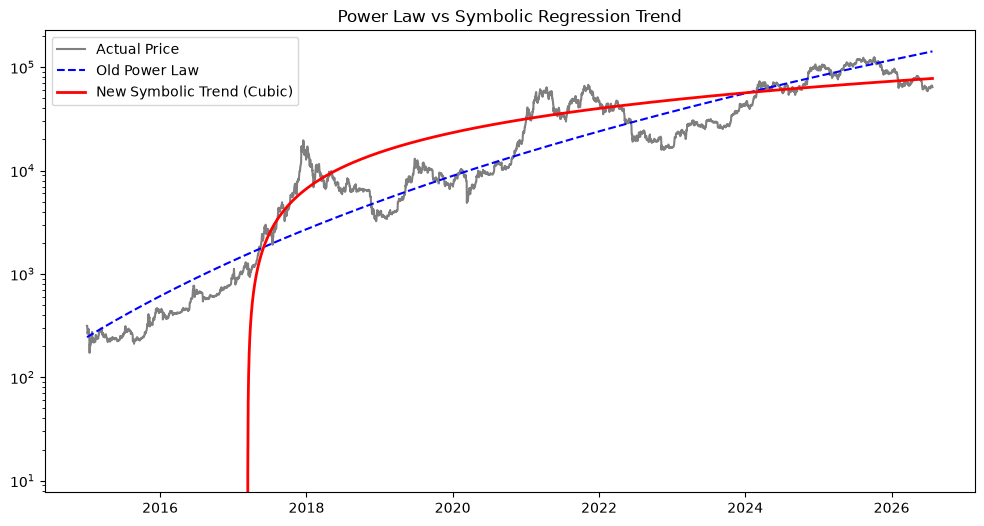

== TRAINING SET (Symbolic Trend Target) ==
 RMSE: 0.1470
 R²: 0.9420

== TEST SET (Symbolic Trend + ETF Flows) ==
 RMSE: 0.3525
 R²: 0.2247

== BENCHMARK (Predicts 0) ==
 RMSE: 0.4026
 R²: -0.0114


In [24]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calculate the NEW Symbolic Regression Trend
df["sym_trend"] = model_sym.predict(df[["days_since_genesis"]].values)

# Calculate new deviation (Log Price - Log Sym Trend)
df["deviation_sym"] = np.log(df["btc_price"]) - np.log(df["sym_trend"])

# Update the features dataframe with the new target
features["deviation_sym"] = df["deviation_sym"]

# Plot the new trend vs the old power law
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["btc_price"], label="Actual Price", color="black", alpha=0.5)
plt.plot(df.index, np.exp(df["power_law_fit"]), label="Old Power Law", color="blue", linestyle="--")
plt.plot(df.index, df["sym_trend"], label="New Symbolic Trend (Cubic)", color="red", linewidth=2)
plt.yscale("log") # Log scale to see the trend better
plt.title("Power Law vs Symbolic Regression Trend")
plt.legend()
plt.show()

# 2. Rebuild XGBoost with the NEW Target
X_cols_expanded = [
    "google_trends_btc_smoothed", "puell_multiple", "addresses_nonzero_balance_zscore",
    "lth_supply_zscore", "exchange_reserves_zscore", "active_addresses_zscore",
    "futures_open_interest_zscore", "global_liquidity_t_pct_change", "treasury_10y_pct_change"
]

lagged_data_sym = pd.DataFrame(index=features.index)
# USE THE NEW TARGET HERE:
lagged_data_sym["target_30d_fwd"] = features["deviation_sym"].shift(-30).rolling(window=30).mean()

for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_sym[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_sym[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_sym[f"{col}_lag20"] = features[col].shift(20)

for i in range(4):
    lagged_data_sym[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

# Add ETF Flows here so the model knows about the 2024 regime shift
if "etf_flows_usd" in features.columns:
    lagged_data_sym["etf_flows_usd_lag1"] = features["etf_flows_usd"].shift(1)
    lagged_data_sym["etf_flows_usd_lag5"] = features["etf_flows_usd"].shift(5)

lagged_data_sym = lagged_data_sym.dropna()

y_sym = lagged_data_sym["target_30d_fwd"]
X_sym = lagged_data_sym.drop(columns=["target_30d_fwd"])

# 3. Train/Test Split
TRAIN_END = "2022-12-31"
X_train_sym, y_train_sym = X_sym.loc[:TRAIN_END], y_sym.loc[:TRAIN_END]
X_test_sym, y_test_sym = X_sym.loc["2023-01-01":], y_sym.loc["2023-01-01":]

# 4. Fit XGBoost
model_xgb_sym = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=150, max_depth=2,
    learning_rate=0.05, subsample=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42
)
model_xgb_sym.fit(X_train_sym, y_train_sym)

# 5. Predict & Evaluate
y_train_pred_sym = model_xgb_sym.predict(X_train_sym)
y_test_pred_sym = model_xgb_sym.predict(X_test_sym)
y_benchmark_sym = np.zeros_like(y_test_sym)

print(f"== TRAINING SET (Symbolic Trend Target) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_sym, y_train_pred_sym)):.4f}")
print(f" R²: {r2_score(y_train_sym, y_train_pred_sym):.4f}")

print(f"\n== TEST SET (Symbolic Trend + ETF Flows) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_sym, y_test_pred_sym)):.4f}")
print(f" R²: {r2_score(y_test_sym, y_test_pred_sym):.4f}")

print(f"\n== BENCHMARK (Predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_sym, y_benchmark_sym)):.4f}")
print(f" R²: {r2_score(y_test_sym, y_benchmark_sym):.4f}")

In [25]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# 1. Split Data first!
TRAIN_END = "2022-12-31"
train_df = df.loc[:TRAIN_END].copy()
test_df = df.loc["2023-01-01":].copy()

# 2. Fit Symbolic Regression ONLY on Training Data
trend_train = train_df[["days_since_genesis", "btc_price"]].dropna()
X_trend_train = trend_train[["days_since_genesis"]].values
y_trend_train = trend_train["btc_price"].values

print("Fitting Symbolic Regression on Training Data Only...")
model_sym_leakfree = PySRRegressor(
    niterations=40, binary_operators=["+", "-", "*", "/"], unary_operators=["log", "exp"],
    population_size=50, parsimony=0.01, maxsize=20, random_state=42, verbosity=0
)
model_sym_leakfree.fit(X_trend_train, y_trend_train)

# Predict trend across BOTH train and test (extrapolating forward)
df["sym_trend_leakfree"] = model_sym_leakfree.predict(df[["days_since_genesis"]].values)
df["deviation_leakfree"] = np.log(df["btc_price"]) - np.log(df["sym_trend_leakfree"])
features["deviation_leakfree"] = df["deviation_leakfree"]

# 3. Fit HMM ONLY on Training Data
print("Fitting HMM on Training Data Only...")
df["returns"] = df["btc_price"].pct_change()
df["volatility"] = df["returns"].rolling(window=30).std()
hmm_data_all = df.loc[features.index, ["returns", "volatility"]].dropna() * 100

# Split HMM data
hmm_train = hmm_data_all.loc[:TRAIN_END]
hmm_test = hmm_data_all.loc["2023-01-01":]

hmm_model_lf = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, random_state=42)
hmm_model_lf.fit(hmm_train)

# Predict probabilities on train and test SEPARATELY (no time machine)
probs_train = hmm_model_lf.predict_proba(hmm_train)
probs_test = hmm_model_lf.predict_proba(hmm_test)

# Assign back to features
for i in range(4):
    features.loc[hmm_train.index, f"regime_{i}_prob"] = probs_train[:, i]
    features.loc[hmm_test.index, f"regime_{i}_prob"] = probs_test[:, i]

# 4. Rebuild XGBoost with the Leak-Free Target
X_cols_expanded = [
    "google_trends_btc_smoothed", "puell_multiple", "addresses_nonzero_balance_zscore",
    "lth_supply_zscore", "exchange_reserves_zscore", "active_addresses_zscore",
    "futures_open_interest_zscore", "global_liquidity_t_pct_change", "treasury_10y_pct_change"
]

lagged_data_lf = pd.DataFrame(index=features.index)
lagged_data_lf["target_30d_fwd"] = features["deviation_leakfree"].shift(-30).rolling(window=30).mean()

for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_lf[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_lf[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_lf[f"{col}_lag20"] = features[col].shift(20)

for i in range(4):
    lagged_data_lf[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

if "etf_flows_usd" in features.columns:
    lagged_data_lf["etf_flows_usd_lag1"] = features["etf_flows_usd"].shift(1)
    lagged_data_lf["etf_flows_usd_lag5"] = features["etf_flows_usd"].shift(5)

lagged_data_lf = lagged_data_lf.dropna()

y_lf = lagged_data_lf["target_30d_fwd"]
X_lf = lagged_data_lf.drop(columns=["target_30d_fwd"])

X_train_lf, y_train_lf = X_lf.loc[:TRAIN_END], y_lf.loc[:TRAIN_END]
X_test_lf, y_test_lf = X_lf.loc["2023-01-01":], y_lf.loc["2023-01-01":]

# 5. Fit XGBoost
model_xgb_lf = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=150, max_depth=2,
    learning_rate=0.05, subsample=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42
)
model_xgb_lf.fit(X_train_lf, y_train_lf)

# 6. Predict & Evaluate
y_train_pred_lf = model_xgb_lf.predict(X_train_lf)
y_test_pred_lf = model_xgb_lf.predict(X_test_lf)
y_benchmark_lf = np.zeros_like(y_test_lf)

print(f"\n== TRAINING SET (Leak-Free) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_lf, y_train_pred_lf)):.4f}")
print(f" R²: {r2_score(y_train_lf, y_train_pred_lf):.4f}")

print(f"\n== TEST SET (Leak-Free) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_lf, y_test_pred_lf)):.4f}")
print(f" R²: {r2_score(y_test_lf, y_test_pred_lf):.4f}")

print(f"\n== BENCHMARK (Predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_lf, y_benchmark_lf)):.4f}")
print(f" R²: {r2_score(y_test_lf, y_benchmark_lf):.4f}")

Fitting Symbolic Regression on Training Data Only...
Fitting HMM on Training Data Only...

== TRAINING SET (Leak-Free) ==
 RMSE: 0.1440
 R²: 0.9425

== TEST SET (Leak-Free) ==
 RMSE: 0.4611
 R²: -0.2667

== BENCHMARK (Predicts 0) ==
 RMSE: 0.5179
 R²: -0.5981


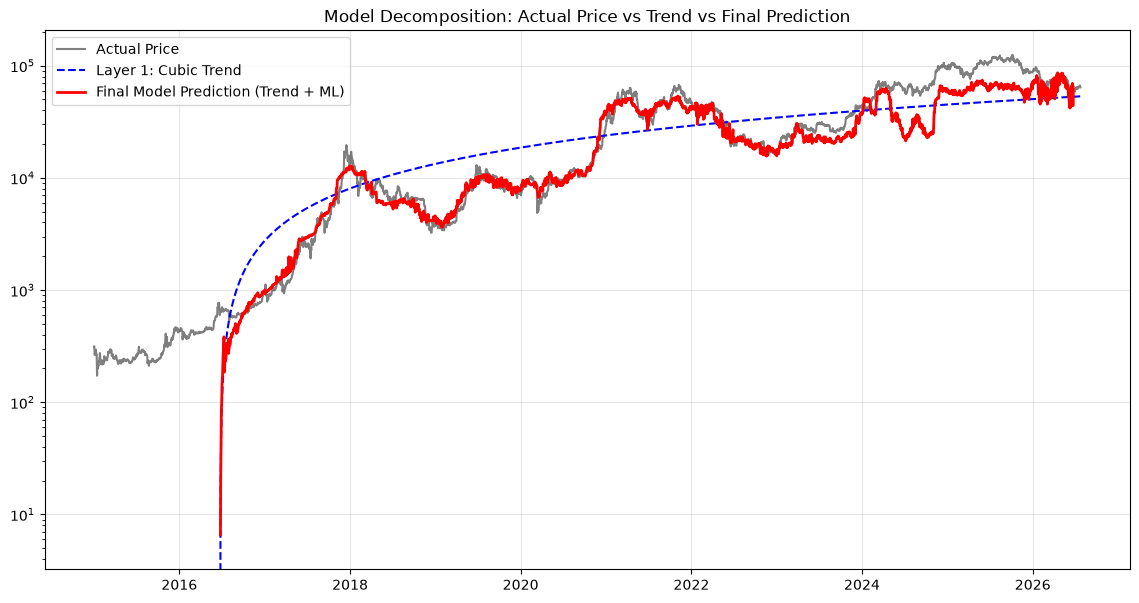

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get the final predictions
# Align the ML predictions to the correct dates
pred_deviation = pd.Series(model_xgb_lf.predict(X_lf), index=X_lf.index)

# Math: Log(Trend) + Predicted Deviation = Predicted Log Price
# Then exp() to get back to dollar amount
trend_log = np.log(df.loc[X_lf.index, "sym_trend_leakfree"])
final_predicted_price = np.exp(trend_log + pred_deviation)

# 2. Plot everything
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["btc_price"], label="Actual Price", color="black", alpha=0.5)
plt.plot(df.index, df["sym_trend_leakfree"], label="Layer 1: Cubic Trend", color="blue", linestyle="--")
plt.plot(final_predicted_price.index, final_predicted_price, label="Final Model Prediction (Trend + ML)", color="red", linewidth=2)

plt.yscale("log") # Log scale so the early years are visible
plt.title("Model Decomposition: Actual Price vs Trend vs Final Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

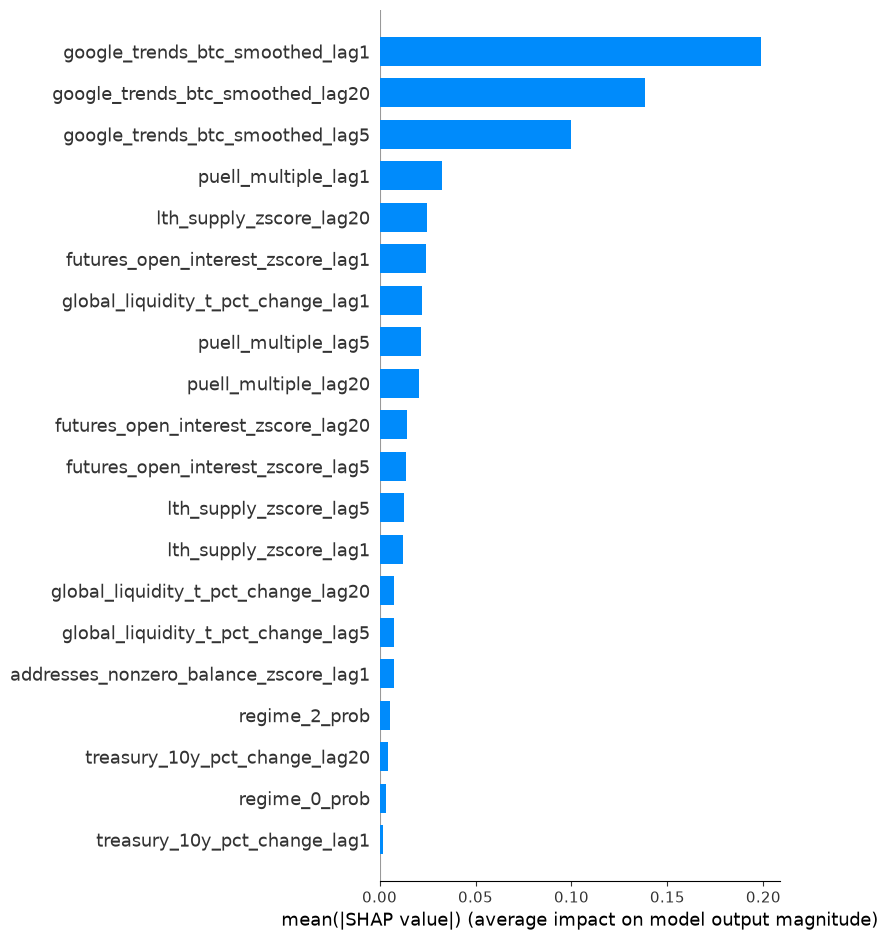

In [27]:
import shap
import matplotlib.pyplot as plt

# Explain the model's predictions using SHAP
explainer = shap.Explainer(model_xgb_lf)
shap_values = explainer(X_test_lf)

# Plot the summary
plt.figure()
shap.summary_plot(shap_values, X_test_lf, plot_type="bar")

In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.api as sm

# 1. Rebuild the v1 Power Law (Fit ONLY on training data to be fair)
train_df = df.loc[:"2022-12-31"].dropna(subset=["log_days", "log_price"])
X_pl = sm.add_constant(train_df["log_days"])
y_pl = train_df["log_price"]
pl_model = sm.OLS(y_pl, X_pl).fit()

# 2. Calculate Trend Predictions for the 2023-2024 Test Set
test_mask = df.index >= "2023-01-01"
test_actual_log_price = df.loc[test_mask, "log_price"]

# Power Law prediction
test_log_days = sm.add_constant(df.loc[test_mask, "log_days"])
power_law_pred = pl_model.predict(test_log_days)

# Symbolic Regression prediction
sym_pred = np.log(df.loc[test_mask, "sym_trend_leakfree"]) # Log it to match units

# 3. Calculate RMSE (Error in Log-Space)
pl_rmse = np.sqrt(mean_squared_error(test_actual_log_price, power_law_pred))
sym_rmse = np.sqrt(mean_squared_error(test_actual_log_price, sym_pred))

print("== LAYER 1 BASELINE AUDIT (Test Set: 2023-2024) ==")
print(f"Power Law RMSE (Log-Space): {pl_rmse:.4f}")
print(f"Symbolic Regression RMSE (Log-Space): {sym_rmse:.4f}")

if sym_rmse < pl_rmse:
    print("\nVERDICT: Symbolic Regression is a BETTER baseline than the Power Law.")
else:
    print("\nVERDICT: Power Law is actually a better baseline. Symbolic Regression added noise.")

== LAYER 1 BASELINE AUDIT (Test Set: 2023-2024) ==
Power Law RMSE (Log-Space): 0.7929
Symbolic Regression RMSE (Log-Space): 0.5197

VERDICT: Symbolic Regression is a BETTER baseline than the Power Law.


In [29]:
import pandas as pd
import numpy as np

# 1. Get the feature matrix for the very last day in the dataset
last_date = X_lf.index.max()
X_today = X_lf.loc[[last_date]]

# 2. Layer 1: Get the Symbolic Regression Trend for today
trend_today = df.loc[last_date, "sym_trend_leakfree"]

# 3. Layer 2: Get the XGBoost predicted deviation for 30 days from now
predicted_deviation = model_xgb_lf.predict(X_today)[0]

# 4. Combine them to get the Final Predicted Price (30-day forward fair value)
log_trend = np.log(trend_today)
predicted_log_price = log_trend + predicted_deviation
final_predicted_price = np.exp(predicted_log_price)

# 5. Get the actual current price for comparison
actual_price_today = df.loc[last_date, "btc_price"]

print(f"Date: {last_date.date()}")
print(f"Actual Current Price: ${actual_price_today:,.2f}")
print(f"Layer 1 Baseline Trend: ${trend_today:,.2f}")
print(f"Predicted Deviation (30d fwd): {predicted_deviation:.4f} (log-space)")
print(f"============================================")
print(f"Model's 30-Day Forward Fair Value: ${final_predicted_price:,.2f}")

Date: 2026-06-23
Actual Current Price: $62,651.71
Layer 1 Baseline Trend: $52,832.60
Predicted Deviation (30d fwd): 0.1989 (log-space)
Model's 30-Day Forward Fair Value: $64,457.19


In [30]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. Revert to the Power Law Deviation Target
# (We calculated this earlier as df["deviation"])
features["deviation_pl"] = df["deviation"]

# 2. Rebuild XGBoost with the Power Law Target
X_cols_expanded = [
    "google_trends_btc_smoothed", "puell_multiple", "addresses_nonzero_balance_zscore",
    "lth_supply_zscore", "exchange_reserves_zscore", "active_addresses_zscore",
    "futures_open_interest_zscore", "global_liquidity_t_pct_change", "treasury_10y_pct_change"
]

lagged_data_pl = pd.DataFrame(index=features.index)
lagged_data_pl["target_30d_fwd"] = features["deviation_pl"].shift(-30).rolling(window=30).mean()

for col in X_cols_expanded:
    if col in features.columns:
        lagged_data_pl[f"{col}_lag1"] = features[col].shift(1)
        lagged_data_pl[f"{col}_lag5"] = features[col].shift(5)
        lagged_data_pl[f"{col}_lag20"] = features[col].shift(20)

for i in range(4):
    lagged_data_pl[f"regime_{i}_prob"] = features[f"regime_{i}_prob"]

if "etf_flows_usd" in features.columns:
    lagged_data_pl["etf_flows_usd_lag1"] = features["etf_flows_usd"].shift(1)
    lagged_data_pl["etf_flows_usd_lag5"] = features["etf_flows_usd"].shift(5)

lagged_data_pl = lagged_data_pl.dropna()

y_pl = lagged_data_pl["target_30d_fwd"]
X_pl = lagged_data_pl.drop(columns=["target_30d_fwd"])

TRAIN_END = "2022-12-31"
X_train_pl, y_train_pl = X_pl.loc[:TRAIN_END], y_pl.loc[:TRAIN_END]
X_test_pl, y_test_pl = X_pl.loc["2023-01-01":], y_pl.loc["2023-01-01":]

# 3. Fit XGBoost
model_xgb_pl = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=150, max_depth=2,
    learning_rate=0.05, subsample=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42
)
model_xgb_pl.fit(X_train_pl, y_train_pl)

# 4. Predict & Evaluate
y_train_pred_pl = model_xgb_pl.predict(X_train_pl)
y_test_pred_pl = model_xgb_pl.predict(X_test_pl)
y_benchmark_pl = np.zeros_like(y_test_pl)

print(f"== TRAINING SET (Power Law Baseline) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_train_pl, y_train_pred_pl)):.4f}")
print(f" R²: {r2_score(y_train_pl, y_train_pred_pl):.4f}")

print(f"\n== TEST SET (Power Law Baseline) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_pl, y_test_pred_pl)):.4f}")
print(f" R²: {r2_score(y_test_pl, y_test_pred_pl):.4f}")

print(f"\n== BENCHMARK (Predicts 0) ==")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test_pl, y_benchmark_pl)):.4f}")
print(f" R²: {r2_score(y_test_pl, y_benchmark_pl):.4f}")

# 5. Get Today's Prediction
last_date = X_pl.index.max()
X_today = X_pl.loc[[last_date]]

trend_today = np.exp(df.loc[last_date, "power_law_fit"])
predicted_deviation = model_xgb_pl.predict(X_today)[0]

log_trend = np.log(trend_today)
predicted_log_price = log_trend + predicted_deviation
final_predicted_price = np.exp(predicted_log_price)

actual_price_today = df.loc[last_date, "btc_price"]

print(f"\n============================================")
print(f"Date: {last_date.date()}")
print(f"Actual Current Price: ${actual_price_today:,.2f}")
print(f"Layer 1 Baseline Trend (Power Law): ${trend_today:,.2f}")
print(f"Predicted Deviation (30d fwd): {predicted_deviation:.4f}")
print(f"Model's 30-Day Forward Fair Value: ${final_predicted_price:,.2f}")

== TRAINING SET (Power Law Baseline) ==
 RMSE: 0.1499
 R²: 0.9362

== TEST SET (Power Law Baseline) ==
 RMSE: 0.6367
 R²: -4.2642

== BENCHMARK (Predicts 0) ==
 RMSE: 0.3546
 R²: -0.6326

Date: 2026-06-23
Actual Current Price: $62,651.71
Layer 1 Baseline Trend (Power Law): $138,077.41
Predicted Deviation (30d fwd): -0.0367
Model's 30-Day Forward Fair Value: $133,102.71


In [32]:
from pysr import PySRRegressor
import numpy as np

# 1. Prepare Data
trend_data = df[["days_since_genesis", "btc_price"]].dropna()
X_trend = trend_data[["days_since_genesis"]].values
y_trend = trend_data["btc_price"].values

# 2. Define the Custom Loss Function (The "Economic Laws")
# PySR takes this as a Julia string, but it compiles and runs very fast.
# We penalize negative predictions heavily. 
# We also penalize non-monotonic behavior (if tomorrow's prediction is lower than today's).
custom_loss_julia = """
function loss(p, y)
    # Standard squared error
    base_loss = sum((p .- y).^2) / length(y)
    
    # Penalty 1: Negative prices (massive penalty)
    neg_penalty = sum(p .< 0.0) * 1e10
    
    # Penalty 2: Non-monotonic (price decreasing as days increase)
    # We check if the prediction drops from the previous day
    mono_penalty = 0.0
    for i in 2:length(p)
        if p[i] < p[i-1]
            mono_penalty += 1e8
        end
    end
    
    return base_loss + neg_penalty + mono_penalty
end
"""

# 3. Configure PySR with Constraints
model_constrained = PySRRegressor(
    niterations=50,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log"],
    population_size=50,
    maxsize=25,
    loss_function=custom_loss_julia, # Inject the economic laws!
    random_state=42,
    verbosity=1
)

print("Fitting Constrained Symbolic Regression...")
model_constrained.fit(X_trend, y_trend)

print("\n--- Discovered Equations (Constrained) ---")
print(model_constrained)

Fitting Constrained Symbolic Regression...


JuliaError: MethodError: no method matching loss(::Node{Float32}, ::SymbolicRegression.CoreModule.DatasetModule.BasicDataset{Float32, Float32, Matrix{Float32}, Vector{Float32}, Nothing, @NamedTuple{}, Nothing, Nothing, Nothing, Nothing}, ::Options{SymbolicRegression.CoreModule.OptionsStructModule.ComplexityMapping{Int64, Int64}, OperatorEnum, Node, Expression, @NamedTuple{}, MutationWeights, false, false, nothing, Nothing, 5})
The function `loss` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  loss(::Any, ::Any)
   @ Main none:1

Stacktrace:
  [1] evaluator(f::typeof(loss), tree::Node{Float32}, dataset::SymbolicRegression.CoreModule.DatasetModule.BasicDataset{Float32, Float32, Matrix{Float32}, Vector{Float32}, Nothing, @NamedTuple{}, Nothing, Nothing, Nothing, Nothing}, options::Options{SymbolicRegression.CoreModule.OptionsStructModule.ComplexityMapping{Int64, Int64}, OperatorEnum, Node, Expression, @NamedTuple{}, MutationWeights, fal

In [33]:
from pysr import PySRRegressor
import numpy as np

# 1. Prepare Data (Log-Transform both sides to enforce economic laws)
trend_data = df[["days_since_genesis", "btc_price"]].dropna()
# We give PySR log(days) and ask it to predict log(price)
X_trend = np.log(trend_data[["days_since_genesis"]].values)
y_trend = np.log(trend_data["btc_price"].values)

# 2. Configure PySR with Operator Constraints
model_constrained = PySRRegressor(
    niterations=40,
    # We remove "exp" to prevent explosions. We keep "log" and "sqrt" to allow deceleration.
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "sqrt"],
    population_size=50,
    maxsize=25,
    parsimony=0.01,
    random_state=42,
    verbosity=1
)

print("Fitting Constrained Symbolic Regression (Log-Log Space)...")
model_constrained.fit(X_trend, y_trend)

print("\n--- Discovered Equations (Constrained) ---")
print(model_constrained)

Fitting Constrained Symbolic Regression (Log-Log Space)...


[ Info: Started!



Expressions evaluated per second: 1.440e+04
Progress: 49 / 1240 total iterations (3.952%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.486e+00  0.000e+00  y = 9.2408
3           2.399e+00  1.869e-01  y = x₀ / 0.89559
5           2.676e-01  1.097e+00  y = (-405.26 / x₀) + 57.998
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.760e+04
Progress: 104 / 1240 total iterations (8.387%)
════════════════════════════════════════════════════════════════════════════════════════════════════
─────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:



--- Discovered Equations (Constrained) ---
PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                                 x0   
	1        1.657620e-01                                     x0 / 0.8955923   
	2  >>>>  1.096664e+00                      (-405.26312 / x0) + 57.998363   
	3        3.014545e-04                   log(x0 + -6.2100224) * 12.352681   
	4        5.758916e-02            log((x0 + x0) + -13.603197) * 8.4658575   
	5        2.619833e-02  ((x0 + -11.293378) * (x0 + -7.2414503)) * -2.9...   
	6        3.444864e-07  (((x0 + -11.375568) * -2.9588692) * (x0 + -7.1...   
	7        2.153041e-08  ((((x0 + -11.460535) * -2.9594502) * (x0 + -7....   
	8        3.875476e-07  ((x0 + -7.4638696) * (-2.784688 * (x0 + -12.22...   
	9        6.702608e-04  (((x0 + -7.1528554) * -3.4682531) * (x0 + -12....   
	
	       loss  complexity  
	0  3.341780           1  
	1  2.398826           3

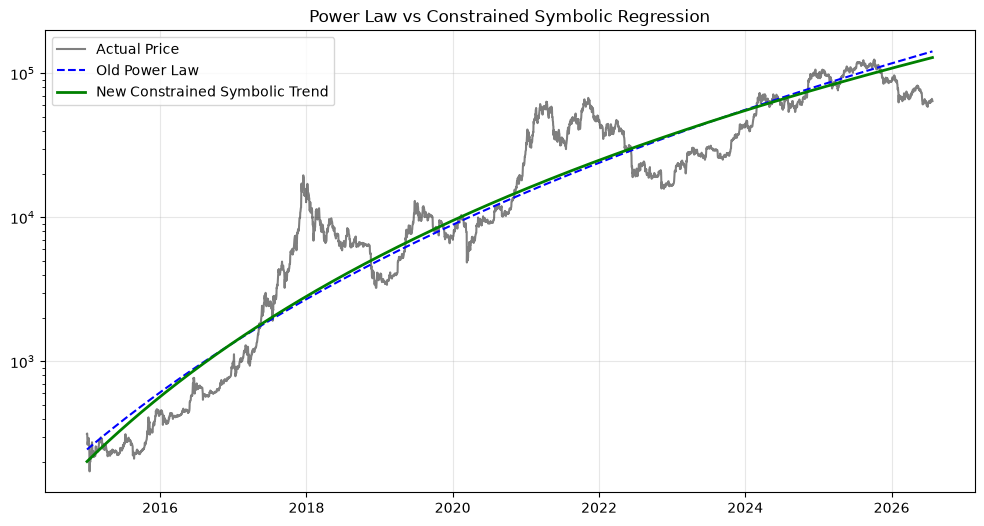

== LAYER 1 AUDIT (Test Set: 2023-2024) ==
Power Law RMSE (Log-Space): 0.7929
Constrained Sym Reg RMSE (Log-Space): 0.3545

VERDICT: The Constrained Symbolic Regression is mathematically superior.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# 1. Calculate the new Constrained Trend across the entire dataset
log_days = np.log(df["days_since_genesis"]).values.reshape(-1, 1)
df["sym_trend_constrained"] = np.exp(model_constrained.predict(log_days))

# 2. Plot it against reality and the old power law
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["btc_price"], label="Actual Price", color="black", alpha=0.5)
plt.plot(df.index, np.exp(df["power_law_fit"]), label="Old Power Law", color="blue", linestyle="--")
plt.plot(df.index, df["sym_trend_constrained"], label="New Constrained Symbolic Trend", color="green", linewidth=2)
plt.yscale("log") # Log scale to see the early years
plt.title("Power Law vs Constrained Symbolic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. The Audit (Test Set: 2023-2024)
# We must fit the Power Law ONLY on training data to be fair
test_mask = df.index >= "2023-01-01"
test_actual_log_price = df.loc[test_mask, "log_price"]

train_df = df.loc[:"2022-12-31"].dropna(subset=["log_days", "log_price"])
pl_model = sm.OLS(train_df["log_price"], sm.add_constant(train_df["log_days"])).fit()
power_law_pred = pl_model.predict(sm.add_constant(df.loc[test_mask, "log_days"]))

# Get Constrained Sym Reg predictions (in log-space)
sym_pred = np.log(df.loc[test_mask, "sym_trend_constrained"])

# Calculate RMSE
pl_rmse = np.sqrt(mean_squared_error(test_actual_log_price, power_law_pred))
sym_rmse = np.sqrt(mean_squared_error(test_actual_log_price, sym_pred))

print("== LAYER 1 AUDIT (Test Set: 2023-2024) ==")
print(f"Power Law RMSE (Log-Space): {pl_rmse:.4f}")
print(f"Constrained Sym Reg RMSE (Log-Space): {sym_rmse:.4f}")

if sym_rmse < pl_rmse:
    print("\nVERDICT: The Constrained Symbolic Regression is mathematically superior.")
else:
    print("\nVERDICT: Power Law is still better. We should revert to it.")

In [35]:
# Extract the winning equation from the PySR model
print("The Constrained Symbolic Regression Equation is:")
print(model_constrained.sympy())

# To see it in standard math format:
print("\nLaTeX format:")
print(model_constrained.latex())

The Constrained Symbolic Regression Equation is:
57.998363 - 405.26312/x0

LaTeX format:
58.0 - \frac{405.}{x_{0}}
